In [ ]:
# Intelligent Customer Churn Prediction & Retention Optimization System

## Week 1: Data Acquisition, Cleaning and Exploratory Analysis

**Internship:** Virtual Data Science with Python Apprentice Intern

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Dataset:** IBM Telco Customer Churn Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
## 1. Data Acquisition

### Dataset Selection

The dataset selected for this project is the IBM Telco Customer Churn dataset.

The dataset contains customer-level information related to demographics,
telecommunication services, account information, billing details, tenure,
and customer churn status.

This dataset was selected because customer churn is a realistic business
problem and the dataset contains both numerical and categorical variables.
It is therefore suitable for data cleaning, exploratory analysis,
statistical analysis, and machine learning in the later stages of this
five-week project.

### Dataset Source

IBM GitHub Repository:
https://github.com/IBM/telco-customer-churn-on-icp4d

The dataset will be acquired directly from the publicly available IBM
repository.

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [5]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


In [9]:
# Missing-value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Columns with missing values:")
print(missing_percentage[missing_percentage > 0])

Columns with missing values:
Series([], dtype: float64)


In [10]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
# Check for duplicate customer IDs
duplicate_customer_ids = df["customerID"].duplicated().sum()

print("Duplicate customer IDs:", duplicate_customer_ids)

Duplicate customer IDs: 0


In [12]:
# Inspect unique values that may cause TotalCharges to be non-numeric
print(df["TotalCharges"].unique()[:20])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']


In [13]:
# Find blank values in TotalCharges
blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()

print("Blank TotalCharges values:", blank_total_charges)

Blank TotalCharges values: 11


In [14]:
# Display rows where TotalCharges is blank
df[df["TotalCharges"].astype(str).str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [15]:
# Display unique values for categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges:
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn:
['No' 'Yes']


In [16]:
# Summary of numerical variables
df.select_dtypes(include=np.number).describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
## 3. Data Cleaning and Preprocessing

Based on the initial data-quality audit, the dataset contained no duplicate rows or duplicate customer IDs. However, the `TotalCharges` column was stored as an object datatype instead of a numeric datatype, and 11 records contained blank values.

The blank `TotalCharges` values correspond to customers with zero months of tenure. Since these customers have just started their service, replacing their total charges with an arbitrary statistical value such as the mean could distort the data. Therefore, the blank values will be treated as missing values and replaced with 0, which is logically consistent with zero accumulated tenure.

The `TotalCharges` column will then be converted to a numeric datatype for accurate statistical analysis and visualization.

In [17]:
# Replace blank TotalCharges values with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Check the number of missing values
print("Missing TotalCharges after conversion:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges after conversion: 11


In [18]:
# Convert TotalCharges from object to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

print("TotalCharges datatype:", df["TotalCharges"].dtype)

TotalCharges datatype: float64


In [19]:
# Fill missing TotalCharges with 0 for customers with zero tenure
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges after cleaning:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges after cleaning: 0


In [20]:
# Verify data types after cleaning
print("Updated data types:")
print(df.dtypes)

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

print("\nDataset shape:")
print(df.shape)

Updated data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values after cleaning:
0

Dataset shape:
(7043, 21)


In [21]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [ ]:
## 4. Exploratory Data Analysis (EDA)

After cleaning the dataset, exploratory data analysis is performed to understand customer characteristics, service usage, billing patterns, and churn distribution.

The analysis focuses on identifying important patterns and relationships that may help explain why customers leave the service.

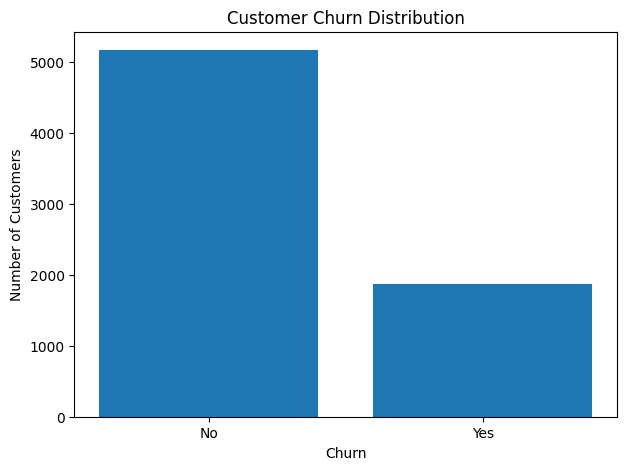

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [22]:
# Churn distribution

import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

print("Churn distribution:")
print(churn_counts)

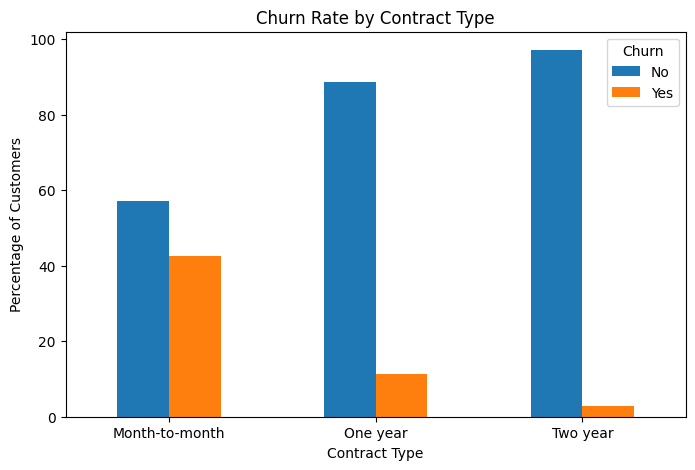

Churn rate by contract type (%):
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [23]:
# Churn rate by contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

print("Churn rate by contract type (%):")
print(contract_churn.round(2))

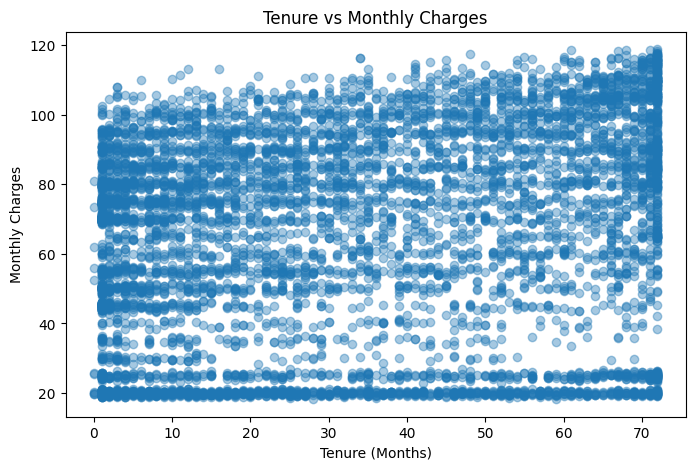

In [24]:
# Relationship between tenure and monthly charges

plt.figure(figsize=(8, 5))

plt.scatter(
    df["tenure"],
    df["MonthlyCharges"],
    alpha=0.4
)

plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.show()

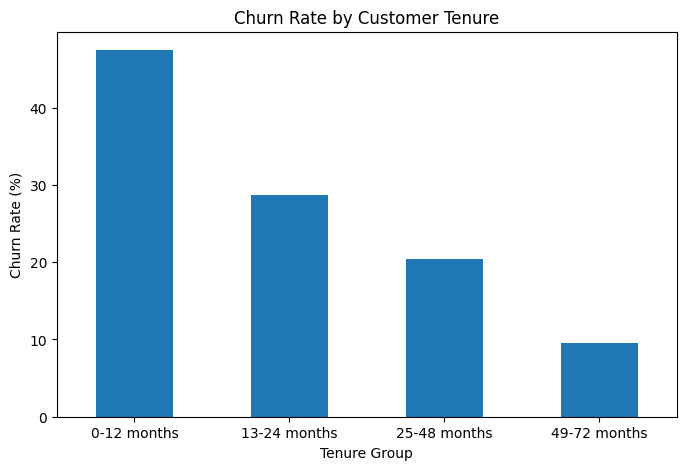

Churn rate by tenure group (%):
TenureGroup
0-12 months     47.44
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Yes, dtype: float64


In [25]:
# Churn rate by tenure group

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

print("Churn rate by tenure group (%):")
print(tenure_churn["Yes"].round(2))

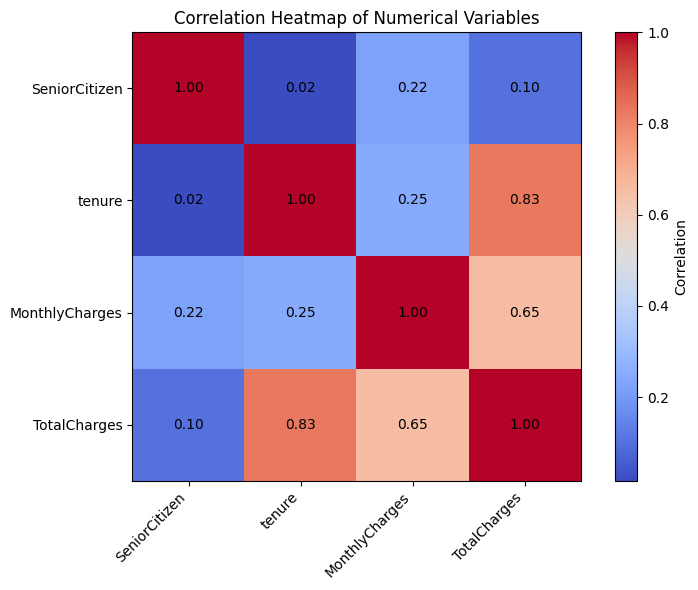

Correlation matrix:
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen            1.00    0.02            0.22          0.10
tenure                   0.02    1.00            0.25          0.83
MonthlyCharges           0.22    0.25            1.00          0.65
TotalCharges             0.10    0.83            0.65          1.00


In [26]:
# Correlation analysis of numerical variables

numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Heatmap of Numerical Variables")

# Add correlation values
for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

print("Correlation matrix:")
print(correlation_matrix.round(2))

In [ ]:
## Key Findings from Exploratory Data Analysis

- The dataset contains 7,043 customers and 21 variables.
- There are no duplicate customer IDs.
- Initially, 11 missing values were found in TotalCharges. These were cleaned and converted to numeric format.
- 1,869 customers have churned, while 5,174 have not churned.
- Month-to-month customers have the highest churn rate (42.71%).
- Customers with longer contracts have much lower churn rates.
- Customers with 0–12 months of tenure have the highest churn rate (47.44%).
- Tenure and TotalCharges have a strong positive correlation (0.83).
- MonthlyCharges and TotalCharges have a moderate positive correlation (0.65).

### Conclusion

The EDA indicates that contract type, customer tenure, and charges are important factors associated with customer churn.